# STEP 1: Validate Time Data

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
USdf = pd.read_csv("database.csv")

In [8]:
USdf['Declaration Date'] = pd.to_datetime(USdf['Declaration Date'], format='%m/%d/%Y')

In [9]:
USdf = USdf.rename(columns={'Disaster Type': 'Incident type'})

In [10]:
USdf['year'] = USdf['Declaration Date'].dt.year
USdf['month'] = USdf['Declaration Date'].dt.month

In [11]:
print(USdf['Declaration Date'].isna().sum(), "missing dates found.")


0 missing dates found.


#  STEP 2: Yearly Trend Analysis

In [12]:
yearly_counts = USdf.groupby('year').size()


In [13]:
type_trends = (
    USdf.groupby(['year', 'Incident type'])
        .size()
        .unstack(fill_value=0)
)

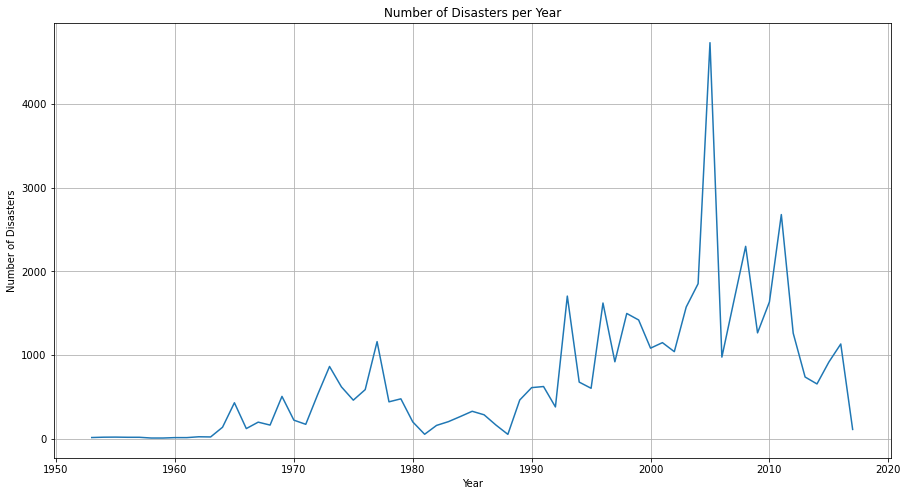

In [14]:
plt.figure(figsize=(15,8))
plt.plot(yearly_counts.index, yearly_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.title("Number of Disasters per Year")
plt.grid(True)
plt.show()

1. What does the graph show?
It shows the total number of disasters per year.

2. What pattern do you observe?
There is an overall increasing trend, with some peak years.

3. What could be the reason?
Climate change, better reporting systems, and population growth in risk-prone areas.

# STEP 3: Incident Type Trends Over Time

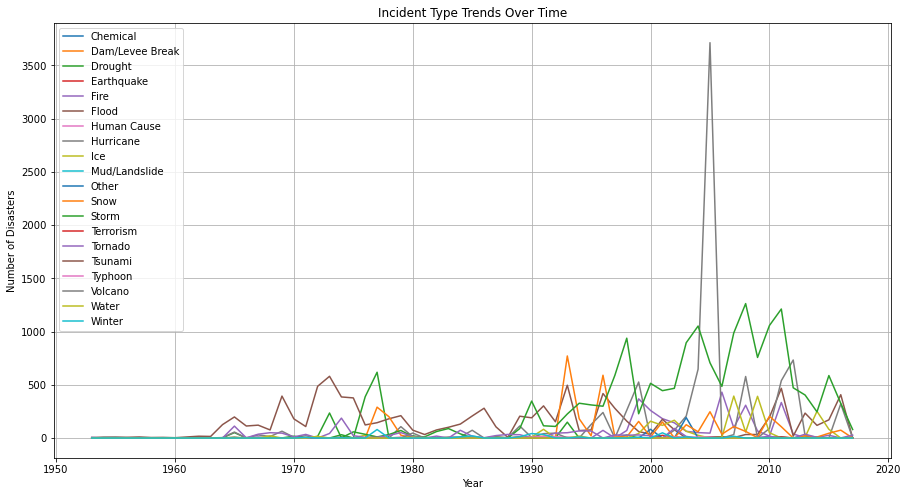

In [15]:
plt.figure(figsize=(15,8))

for column in type_trends.columns:
    plt.plot(type_trends.index, type_trends[column], label=column)

plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.title("Incident Type Trends Over Time")
plt.legend()
plt.grid(True)

plt.show()

1. What does the graph show?
It shows how different disaster types change over the years.

2. What pattern do you observe?
Floods and storms occur more frequently. Some types show an increasing trend.

3. What could be the reason?
Seasonal weather patterns and increasing extreme weather events.

# STEP 4: Seasonality Analysis (Monthly Trends)

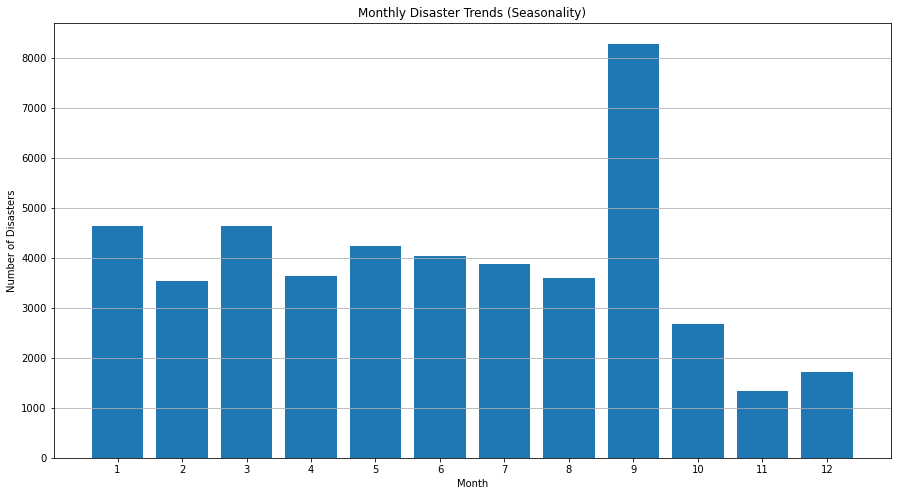

In [16]:
monthly_counts = USdf.groupby('month').size()

plt.figure(figsize=(15,8))
plt.bar(monthly_counts.index, monthly_counts.values)

plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.title("Monthly Disaster Trends (Seasonality)")
plt.xticks(range(1,13))  
plt.grid(axis='y')

plt.show()

1. What does the graph show?
It shows disaster frequency for each month.

2. What pattern do you observe?
Certain months have higher disaster counts, showing seasonality.

3. What could be the reason?
Hurricane season, monsoon periods, winter storms, and summer wildfires.

# STEP 5: Advanced Time Insights 

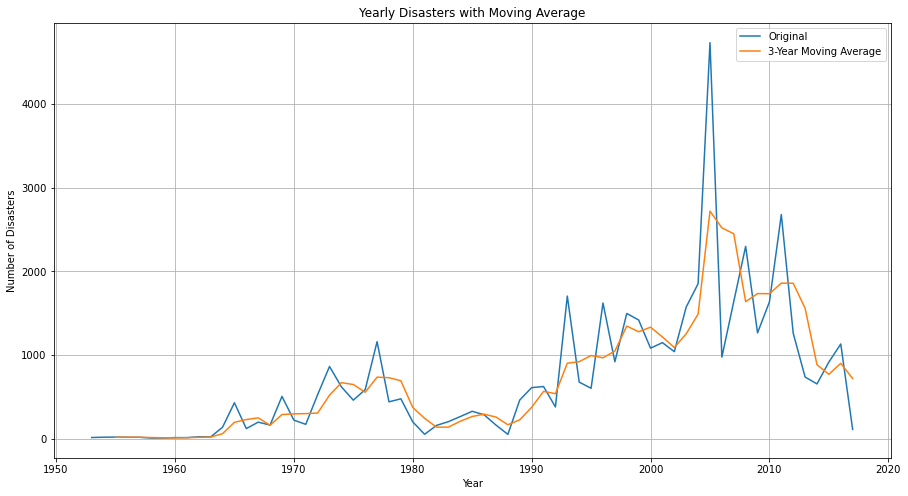

In [20]:
yearly_counts = USdf.groupby('year').size()
rolling_avg = yearly_counts.rolling(window=3).mean()
plt.figure(figsize=(15,8))
plt.plot(yearly_counts.index, yearly_counts.values, label="Original")
plt.plot(rolling_avg.index, rolling_avg.values, label="3-Year Moving Average")

plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.title("Yearly Disasters with Moving Average")
plt.legend()
plt.grid(True)
plt.show()

1. What does the graph show?
It shows the smoothed trend of disasters using a 3-year moving average.

2. What pattern do you observe?
The overall long-term trend is increasing, with reduced short-term fluctuations.

3. What could be the reason?
Climate change, increasing extreme weather events, and better disaster reporting systems.


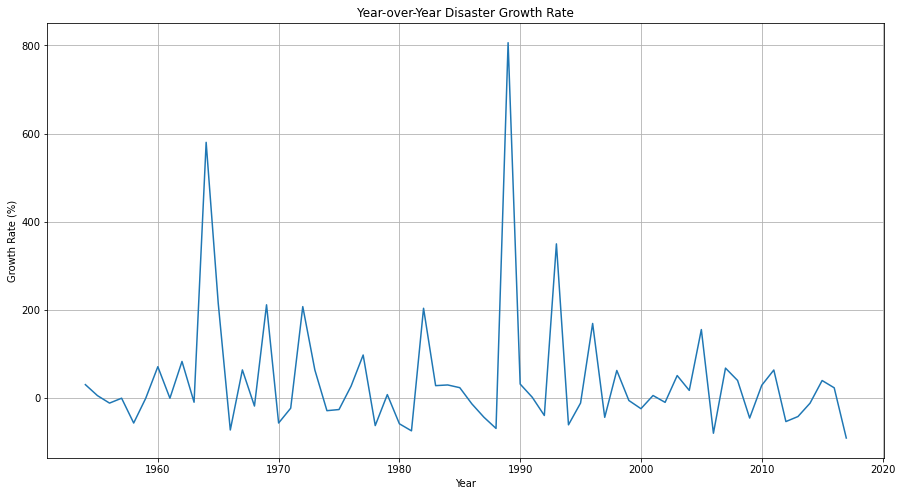

In [21]:
growth_rate = yearly_counts.pct_change() * 100
plt.figure(figsize=(15,8))
plt.plot(growth_rate.index, growth_rate.values)

plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.title("Year-over-Year Disaster Growth Rate")
plt.grid(True)
plt.show()

1. What does the graph show?
It shows the yearly percentage increase or decrease in disasters.

2. What pattern do you observe?
Some years show sharp growth, while others show decline, indicating irregular fluctuations.

3. What could be the reason?
Certain years may have severe hurricane or wildfire seasons, causing sudden spikes.

In [19]:
top_years = yearly_counts.sort_values(ascending=False).head(5)
print("Top 5 Peak Disaster Years:")
print(top_years)

Top 5 Peak Disaster Years:
year
2005    4736
2011    2680
2008    2300
2004    1853
1993    1705
dtype: int64


1. What does the output show?
It identifies the years with the highest number of disasters.

2. What pattern do you observe?
A few specific years stand out with significantly higher disaster counts.

3. What could be the reason?
Those years may have experienced multiple major natural events such as hurricanes, floods, or wildfires.